# GrainSpotter input generation and result visualization

This example prepares GrainSpotter input from a single crystal Nb scan, runs the ImageD11 peak search and g-vector conversion steps, writes a `GrainSpotter.ini` file, and visualizes GrainSpotter assignments on the detector image afterwards.


**Required** external tools:
- `ImageD11` for peak search and `.gve` generation;
- `GrainSpotter` executable for indexing;



## 1. Imports


In [ ]:
from pathlib import Path
import subprocess
import numpy as np, os, glob
import matplotlib.pyplot as plt

from ImageD11 import labelimage
from ImageD11 import transformer

from pyhectr.read_plot import (
    read_P07_imgs_with_metadata as read_imgs_with_metadata,
    image_slider_with_spt,
    grain_slider_on_max_image,
    compute_max_pixel_image,
)
from pyhectr.grainspotter import (
    parse_spt_table,
    group_peaks_by_frame,
    build_multigrain_table,
    build_spot_coord_table,
    build_reflections_table
    )

%matplotlib widget

## 2. Load experimental data

Use the measured omega values from metadata. `read_P07_imgs_with_metadata` returns one metadata row per frame.

In [12]:
InputDir = '/asap3/petra3/gpfs/p07/2024/data/11020129/raw/varex/'
Scan = 'align_00826'
Experiments = sorted(next(os.walk(InputDir))[1])
img_path_pattern = InputDir + Scan + '/*[0-9].tif'
PATH2SAVE = Path("gvec")
PATH2SAVE.mkdir(parents=True, exist_ok=True)


ROIy = slice(0, 2200) # vertical
ROIx = slice(0, 2880) # horizontal

GREEDY = False
if GREEDY:
    ## if you need only max pixel image, this function creates image in greedy way
    max_pixel = compute_max_pixel_image(img_path_pattern, ROIx, ROIy)
    plt.figure()
    plt.imshow(max_pixel, vmax= 350)
    plt.show()
else:
    # loading full scan
    path_to_files = sorted(glob.glob(img_path_pattern))
    data, omega_metadata = read_imgs_with_metadata(img_path_pattern, ROIx, ROIy)
    print('number of images: ', len(data))


omega_metadata = np.asarray(omega_metadata, dtype=float)
omes = (
    omega_metadata
    if omega_metadata.ndim == 1
    else omega_metadata[:, 0]
)


if data.ndim != 3:
    raise ValueError("data must have shape (n_frames, rows, columns)")
if omes.shape != (len(data),):
    raise ValueError("one omega value is required for every image")
if not np.all(np.isfinite(omes)):
    raise ValueError("omega metadata contains non-finite values")


unique_omega = np.sort(np.unique(omes))
if len(unique_omega) < 2:
    raise ValueError("at least two distinct omega values are required")
omega_step = float(np.median(np.abs(np.diff(unique_omega))))
print("median omega step:", omega_step)

number of images:  625


## 3. Run ImageD11 peak search

This step writes the 2D peak table (`.spt`) and merged 3D peak table (`.flt`).


In [28]:
# 1)  the true per frame omegas from metadata
frames = np.asarray(data).copy()                 
omegas =  np.asarray(omes)

order  = np.argsort(omegas)
H, W   = frames.shape[1:]
thr    = 9000.0
base_filename = f"peaks_t{int(thr)}"

total_2d_peaks = 0
spt_path = PATH2SAVE / f"{base_filename}.spt"
flt_path = PATH2SAVE / f"{base_filename}.flt"


with spt_path.open("w") as spt, flt_path.open("w") as flt:
    lio = labelimage.labelimage((H, W), fileout=flt, sptfile=spt)
    spt.write(lio.titles)

    for i in order:
        lio.peaksearch(frames[i], thr, omegas[i])
        total_2d_peaks += int(lio.npk)
        if lio.npk > 0:
            lio.output2dpeaks(spt)
            lio.mergelast()

    lio.finalise()
    merged_spots = int(lio.spot3d_id)

print("2-D peaks seen:", total_2d_peaks)
print("merged 3-D spots:", merged_spots)
print("SPT lines:", sum(1 for _ in spt_path.open()))
print("wrote:", spt_path, flt_path)

2-D peaks seen: 0
3-D spots merged so far: 39
SPT lines: 1072
Wrote: ['gvec/peaks_t9000.flt', 'gvec/peaks_t9000.spt']


## 4. Inspect detected peaks on the detector frames

The slider overlays the merged ImageD11 `.flt` peak positions on the raw frames. Using `.flt` here keeps `peak_id` consistent with the `.gve` file and the later GrainSpotter reflection table.


In [31]:
peaks_list = parse_spt_table(f"{PATH2SAVE}/{base_filename}.flt")
peaks_by_frame = group_peaks_by_frame(peaks_list, omegas=omes, tol_deg=5.5)

In [33]:
peaks_list[0]

{'sc': 1151.6643,
 'fc': 608.6553,
 'omega': -34.7185,
 'number_of_pixels': 66.0,
 'avg_intensity': 14505.9122,
 's_raw': 1151.6643,
 'f_raw': 608.6553,
 'sigs': 2.4559,
 'sigf': 2.7276,
 'covsf': -0.7301,
 'sigo': 1.003,
 'covso': 0.0,
 'covfo': -0.0016,
 'sum_intensity': 957390.2051,
 'sum_intensity^2': 15398843934.1141,
 'imax_int': 26972.1992,
 'imax_s': 1152.0,
 'imax_f': 608.0,
 'imax_o': -34.7546,
 'min_s': 1147.0,
 'max_s': 1157.0,
 'min_f': 603.0,
 'max_f': 614.0,
 'min_o': -34.7546,
 'max_o': -34.5547,
 'dety': -608.6553,
 'detz': 1151.6643,
 'onfirst': 0.0,
 'onlast': 0.0,
 'spot3d_id': 0.0}

In [34]:
peaks_by_frame

{0: [{'sc': 1151.6643,
   'fc': 608.6553,
   'omega': -34.7185,
   'number_of_pixels': 66.0,
   'avg_intensity': 14505.9122,
   's_raw': 1151.6643,
   'f_raw': 608.6553,
   'sigs': 2.4559,
   'sigf': 2.7276,
   'covsf': -0.7301,
   'sigo': 1.003,
   'covso': 0.0,
   'covfo': -0.0016,
   'sum_intensity': 957390.2051,
   'sum_intensity^2': 15398843934.1141,
   'imax_int': 26972.1992,
   'imax_s': 1152.0,
   'imax_f': 608.0,
   'imax_o': -34.7546,
   'min_s': 1147.0,
   'max_s': 1157.0,
   'min_f': 603.0,
   'max_f': 614.0,
   'min_o': -34.7546,
   'max_o': -34.5547,
   'dety': -608.6553,
   'detz': 1151.6643,
   'onfirst': 0.0,
   'onlast': 0.0,
   'spot3d_id': 0.0}],
 1: [{'sc': 1130.1873,
   'fc': 2233.2444,
   'omega': -34.4613,
   'number_of_pixels': 28.0,
   'avg_intensity': 17297.2786,
   's_raw': 1130.1873,
   'f_raw': 2233.2444,
   'sigs': 1.4194,
   'sigf': 1.4989,
   'covsf': 0.1716,
   'sigo': 1.0105,
   'covso': 0.0559,
   'covfo': 0.0619,
   'sum_intensity': 484323.8018,
   

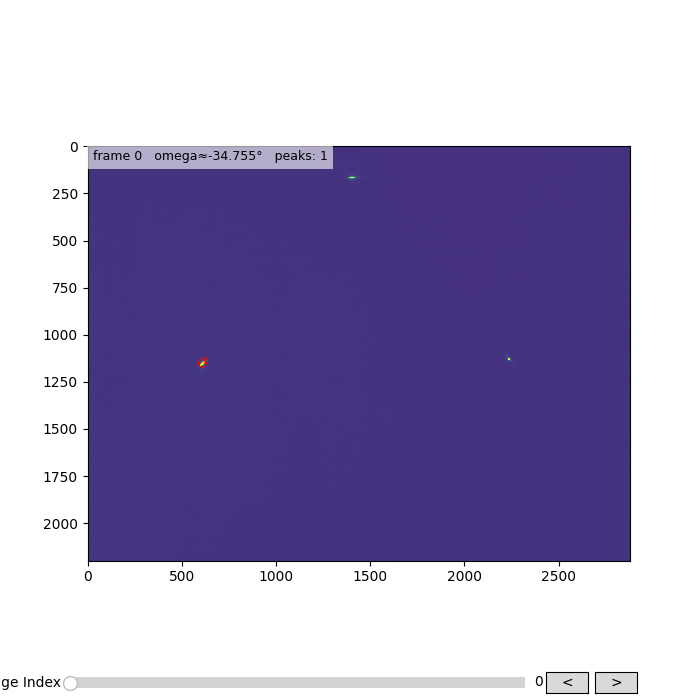

In [35]:
image_slider_with_spt(frames, omes, peaks_by_frame, fig_size=(7,7),
                      vmax=950, cmap='viridis', size_by=None, annotate=True, origin='upper');

In [ ]:
data_filtered_pxl_im = data.max(axis=0)

plt.figure()
plt.imshow(data_filtered_pxl_im[:], vmax=9000, origin='upper')
plt.show()

## 5. Configuration

ImageD11 uses detector distances and pixel sizes in micrometres in the `.prm` file.

In [37]:
SDD_mm   = 1486.857
lam      = 0.16932734739475784
x0, y0   = 1435.227, 2200 - 105.155         # x0=cols (horiz=y), y0=rows (vert=z)
pix_mm   = 0.15
incidence_ang = 0.03

cell_a = cell_b = cell_c = 3.3004
cell_alpha = cell_beta = cell_gamma = 90.0
lattice = "I"                 # Im-3m

In [38]:
x0, y0

(1435.227, 2094.845)

In [39]:
data.shape

(625, 2200, 2880)

## 6. Write ImageD11 geometry file and compute g-vectors

The `.prm` file stores detector geometry and the Nb unit cell. The `.gve` file generated from the merged `.flt` peaks is the main GrainSpotter input.


In [48]:
prm = f"""\
cell__a {cell_a}
cell__b {cell_b}
cell__c {cell_c}
cell_alpha {cell_alpha}
cell_beta {cell_beta}
cell_gamma {cell_gamma}
cell_lattice_[P,A,B,C,I,F,R] {lattice}
distance {SDD_mm*1000}
wavelength {lam}
y-center {x0}
z-center {y0}
y-size {pix_mm*1000.0}
z-size {pix_mm*1000.0}
wedge 0.0
o11 1
o12 0
o21 0
o22 1
tilt_x 0.0
tilt_y 0.0
tilt_z 0.0
t_x 0.0
t_y 0.0
t_z 0.0
"""
open(f"{PATH2SAVE}/geom.prm","w").write(prm)
print(f"wrote {PATH2SAVE}/geom.prm")

wrote gvec/geom.prm


In [49]:
flt_path = f"{PATH2SAVE}/{base_filename}.flt"   # merged-3D peaks file
T = transformer.transformer()
T.loadfiltered(flt_path)
T.loadfileparameters(f"{PATH2SAVE}/geom.prm")   
T.compute_tth_eta()
T.addcellpeaks()                   
T.computegv()
T.savegv(f"{PATH2SAVE}/peaks.gve")
print(f"{PATH2SAVE}/peaks.gve written")

84.8252 -34.7185
gvec/peaks.gve written


## 7. Write GrainSpotter input file

`filespecs` tells GrainSpotter which `.gve` file to read and where to write the `.log` output.


In [50]:
ini_text = """\
spacegroup 229
etarange 0 360
domega 0.2
tthrange 0 15
omegarange -35 90
filespecs peaks.gve grains.log
cuts 4 0.1
eulerstep 2
uncertainties 0.12 0.15 0.25
nsigmas 2
positionfit
"""

with open(f"{PATH2SAVE}/GrainSpotter.ini", "w") as f:
    f.write(ini_text)
print("GrainSpotter.ini written")

GrainSpotter.ini written


**Optional**


If `GrainSpotter` is on `PATH`, the cell below can run it directly. 
Otherwise run the printed shell command manually and continue from the produced `grains.log`.


In [ ]:
#  Optional

# RUN_GRAINSPOTTER = False

# if RUN_GRAINSPOTTER:
#     subprocess.run(
#         ["GrainSpotter", "GrainSpotter.ini"],
#         cwd=PATH2SAVE,
#         check=True,
#     )

## 8. Parse GrainSpotter results

The parser returns both the raw grain dictionaries and convenient tables for plotting and orientation inspection.


### Checking patterns 

In [18]:
log_path = os.path.join(PATH2SAVE, 'grains.log')
refl_df = build_reflections_table(log_path)

In [ ]:
spot_df = build_spot_coord_table(peaks_by_frame)

In [26]:
# .log file is from GrainSpotter
log_path = f"{PATH2SAVE}/grains.log" 
axes_df = build_multigrain_table(log_path, 
                                 axes=('x','y','z'), 
                                 max_index=6, 
                                 order_indices=(0, 2, 1),
                                 a=cell_a)


print(f"Parsed {axes_df.index.get_level_values(0).nunique()} grains; rows = {len(axes_df)}")
axes_df

Parsed 1 grains; rows = 3


phi1        PHI       phi2  mean_IA  pos_x  pos_y  pos_z  \
grain_id axis                                                                  
1        x     26.687927  72.632136  29.231912   0.0898  0.096 -0.045 -0.047   
         y     26.687927  72.632136  29.231912   0.0898  0.096 -0.045 -0.047   
         z     26.687927  72.632136  29.231912   0.0898  0.096 -0.045 -0.047   

                                          crys_dir_axis hkl_from_plane_reduce  \
grain_id axis                                                                   
1        x     (0.714211789, 0.428653934, -0.553314852)           (12, 7, -9)   
         y     (0.522178086, -0.852731056, 0.013408684)           (7, -11, 0)   
         z      (0.466081072, 0.298505531, 0.832864264)            (6, 4, 11)   

               ang_plane_vs_hkl_reduce_deg  ...  \
grain_id axis                               ...   
1        x                        0.889045  ...   
         y                        1.252778  ...   
         z                        0.681708  ...   

                                      plane_normal_frac  \
grain_id axis                                             
1        x      (2.357184603, 1.41472945, -1.826160347)   
         y     (1.723396566, -2.814353592, 0.044254022)   
         z        (1.53825398, 0.98518766, 2.748785232)   

               ang_axis_vs_ub_plane_deg  ang_frac_vs_ub_hkl_deg  \
grain_id axis                                                     
1        x                     0.855200                0.855200   
         y                     0.926514                0.926514   
         z                     2.270237                2.270237   

              euler_axisX_mis_deg  euler_axisY_mis_deg euler_axisZ_mis_deg  \
grain_id axis                                                                
1        x                 0.8552             0.926514            2.270237   
         y                 0.8552             0.926514            2.270237   
         z                 0.8552             0.926514            2.270237   

               euler_axisX_uvw  euler_axisY_uvw  euler_axisZ_uvw  \
grain_id axis                                                      
1        x          (5, 3, -4)       (3, -5, 0)        (3, 2, 5)   
         y          (5, 3, -4)       (3, -5, 0)        (3, 2, 5)   
         z          (5, 3, -4)       (3, -5, 0)        (3, 2, 5)   

               ang_euler_axis_vs_ub_plane_deg  
grain_id axis                                  
1        x                           0.000001  
         y                           0.000001  
         z                           0.000000  

[3 rows x 25 columns]

## 9. Visualize indexed reflections by grain

The final viewer overlays reflections assigned to one GrainSpotter grain on the detector maximum image. The title shows the grain orientation and the nearest compact `(hkl)` / `[uvw]` labels computed from the GrainSpotter orientation matrices.


In [ ]:
state = grain_slider_on_max_image(
    max_image=data_filtered_pxl_im[:],
    refl_df=refl_df,
    spot_df=spot_df,
    orient_df=axes_df,  #
    vmax=200,
    origin='upper',
    annotate=True,
    preferred_axis='z'  # use 'z' orientation (surface normal) for label
)